In [1]:
# csed

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.stats import chi2_contingency

import os
import re

from scipy.stats import gaussian_kde, ks_2samp, mannwhitneyu

In [2]:
DIR = "./data/raw/"
files = os.listdir(DIR)
files = sorted(files)

for x in files:
    print(x)
    
ALPHA = 0.05

01-Grades_CSE100_2022-4_Fall.xlsx
02-Grades_CSE100_2023-1_Winter.xlsx
03-Grades_CSE100_2023-4_Fall.xlsx
04-Grades_CSE100_2024-1_Winter.xlsx
05-Grades_CSE100_2024-2_Spring.xlsx
06-Grades_CSE100_2024-4_Fall.xlsx
07-Grades_CSE100_2025-1_Winter.xlsx
08-Grades_CSE100_2025-4_Fall.xlsx


## Read and preprocess
Read and preprocess files from Winter 2025 and Fall 2025.

In [3]:
def get_df(f):
    """ Read in the grades excel file, skip first row """
    print(f'Reading {f}')
    df = pd.read_excel(DIR + f)  # Skip the first two rows of metadata
    df = df.iloc[1:] # Remove the first row ("points out of")
    return df

df1 = get_df(files[6])
df2 = get_df(files[7])

df1['quarter'] = 'winter'
df1['year'] = 2025
df1['course'] = df1['quarter'].astype(str) + df1['year'].astype(str)

df2['quarter'] = 'fall'
df2['year'] = 2025
df2['course'] = df2['quarter'].astype(str) + df2['year'].astype(str)

def select_and_rename(df):
    """ Selects columns from df that have '.1' in their name, which are 
        duplicate column names. The duplicate columns are the ones we care 
        about, and the original columns have raw point data.
        Renames them by removing the ' (1)' suffix, 
        and returns the resulting dataframe.
    """
    renamed = {}
    df_cols = []
    new_df_cols = []
    for x in df.columns:
        if '.1' in x:
            renamed[x] = x.split(' (')[0]
            df_cols.append(x)
            new_df_cols.append(renamed[x])
        if x in ['quarter', 'course',
                 'Preparation', 'Application', 'Examination', 
                 'Total']:
            df_cols.append(x)
            new_df_cols.append(x)

    df = df[df_cols]
    df = df.rename(columns=renamed)
    return df


df1_sel = select_and_rename(df1)
df2_sel = select_and_rename(df2)

df1_sel['min_category'] = df1_sel[['Preparation', 'Application', 'Examination']].idxmin(axis=1)
df2_sel['min_category'] = df2_sel[['Preparation', 'Application', 'Examination']].idxmin(axis=1)

df1_sel.rename(columns={'Total': 'Overall'}, inplace=True)
df2_sel.rename(columns={'Total': 'Overall'}, inplace=True)

df1_sel['atrisk'] = df1_sel['Overall'] < 57.5
df2_sel['atrisk'] = df2_sel['Overall'] < 57.5

df = pd.concat([df1_sel, df2_sel], ignore_index=True)
df_sub = df[['Preparation','Application', 'Examination', 'Overall', 'course', 'min_category', 'atrisk']]

df1_sel.to_csv("data/processed/df1_sel.csv", index=False)
df2_sel.to_csv("data/processed/df2_sel.csv", index=False)
df_sub.to_csv("data/processed/df_sub.csv", index=False)

print(f"Description of df_sub:\n{df_sub.describe()}\n")
print(f"Description of df1_sel:\n{df1_sel.describe()}\n")
print(f"Description of df2_sel:\n{df2_sel.describe()}\n")



Reading 07-Grades_CSE100_2025-1_Winter.xlsx
Reading 08-Grades_CSE100_2025-4_Fall.xlsx
Description of df_sub:
       Preparation  Application  Examination     Overall
count   852.000000    852.00000   852.000000  852.000000
mean     91.192043     94.74877    90.772863   86.740027
std      10.968626      8.77115    11.250158   12.910712
min      36.260000     23.66700     0.000000    0.000000
25%      88.114583     93.50000    88.656771   82.160833
50%      95.506410     98.00000    94.366023   91.282292
75%      99.666667    100.00000    97.500000   95.674419
max     100.000000    100.00000   100.000000  100.000000

Description of df1_sel:
          Midterm       Final   Project 1   Project 2  \
count  491.000000  491.000000  491.000000  491.000000   
mean     0.935628    0.904992    0.876558    0.910183   
std      0.127028    0.129105    0.230908    0.198484   
min      0.000000    0.000000    0.000000    0.000000   
25%      0.929412    0.879767    0.900000    0.850000   
50%      0.

## Chi-squared tests
Chi-squared tests for distribution of students' min grade categories.

In [4]:
def get_ct_from_df(ct_df, feature='atrisk'):
    ct = pd.crosstab(ct_df[feature], ct_df["min_category"])
    ct = ct[['Preparation', 'Application', 'Examination']]
    
    chi2, p, dof, expected = chi2_contingency(ct)

    return ct, chi2, p, dof, expected

def fmt_p(p):
    if p < 0.001:
        return f"{p:.2e}".replace("e-16", r"\times 10^{-16}")  # optional
    return f"{p:.2f}"

def get_props(ct):
    props = (ct.div(ct.sum(axis=1), axis=0) * 100).round(1)
    print(props, '\n')
    return props

def latex_sci(x):
    base, exp = f"{x:.2e}".split("e")
    exp = int(exp)
    return rf"${base} \times 10^{{{exp}}}$"

def latex_min_category_table(df_sub):
    
    # Overall Q1 vs Q2
    ct_all, chi2_all, p_all, dof_all, expected_all = get_ct_from_df(
        df_sub,
        feature='course')
    props_all = get_props(ct_all)

    # Pass/fail within Q1
    ct_q1, chi2_q1, p_q1, dof_q1, expected_q1 = get_ct_from_df(
        df_sub[df_sub["course"] == "winter2025"],
        feature='atrisk'
    )
    props_q1 = get_props(ct_q1)

    # Pass/fail within Q2
    ct_q2, chi2_q2, p_q2, dof_q2, expected_q2 = get_ct_from_df(
        df_sub[df_sub["course"] == "fall2025"],
        feature='atrisk'
    )
    props_q2 = get_props(ct_q2)

    latex = rf"""
\begin{{table}}[t]
\centering
\caption{{Distribution of students' lowest grade categories.}}
\label{{tab:min-category-distribution}}
\begin{{tabular}}{{lcccc}}
\toprule
Group & Prep. & Appl. & Exam. & $\chi^2$ $p$-value \\
\midrule
Q1 (remote) &
{props_all.loc['winter2025', 'Preparation']}\% &
{props_all.loc['winter2025', 'Application']}\% &
{props_all.loc['winter2025', 'Examination']}\% &
\multirow{{2}}{{*}}{{{latex_sci(p_all)}}} \\
Q2 (in-person) &
{props_all.loc['fall2025', 'Preparation']}\% &
{props_all.loc['fall2025', 'Application']}\% &
{props_all.loc['fall2025', 'Examination']}\% &
\\
\midrule
Passing Q1 &
{props_q1.loc[False, 'Preparation']}\% &
{props_q1.loc[False, 'Application']}\% &
{props_q1.loc[False, 'Examination']}\% &
\multirow{{2}}{{*}}{{{latex_sci(p_q1)}}} \\
Failing Q1 &
{props_q1.loc[True, 'Preparation']}\% &
{props_q1.loc[True, 'Application']}\% &
{props_q1.loc[True, 'Examination']}\% &
\\
\midrule
Passing Q2 &
{props_q2.loc[False, 'Preparation']}\% &
{props_q2.loc[False, 'Application']}\% &
{props_q2.loc[False, 'Examination']}\% &
\multirow{{2}}{{*}}{{{latex_sci(p_q2)}}} \\
Failing Q2 &
{props_q2.loc[True, 'Preparation']}\% &
{props_q2.loc[True, 'Application']}\% &
{props_q2.loc[True, 'Examination']}\% &
\\
\bottomrule
\end{{tabular}}
\end{{table}}
    """
    print(latex)
    
latex_min_category_table(df_sub)

min_category  Preparation  Application  Examination
course                                             
fall2025             30.5          8.0         61.5
winter2025           48.7         18.9         32.4 

min_category  Preparation  Application  Examination
atrisk                                             
False                48.9         18.7         32.3
True                 42.9         23.8         33.3 

min_category  Preparation  Application  Examination
atrisk                                             
False                30.9          8.4         60.7
True                 20.0          0.0         80.0 


\begin{table}[t]
\centering
\caption{Distribution of students' lowest grade categories.}
\label{tab:min-category-distribution}
\begin{tabular}{lcccc}
\toprule
Group & Prep. & Appl. & Exam. & $\chi^2$ $p$-value \\
\midrule
Q1 (remote) &
48.7\% &
18.9\% &
32.4\% &
\multirow{2}{*}{$1.07 \times 10^{-16}$} \\
Q2 (in-person) &
30.5\% &
8.0\% &
61.5\% &
\\
\midrule
Passing 

## Mann-Whitney U-Tests

Mann-Whitney U-Tests for differences in course grades between Q1 and Q2.

In [5]:
cols = ["Preparation", "Application", "Examination", "Overall"]

def fmt_p_latex(p):
    if p < 0.001:
        base, exp = f"{p:.2e}".split("e")
        return rf"${float(base):.2f}\times 10^{{{int(exp)}}}$"
    return f"{p:.2f}"

def fmt_p_readable(p):
    return f"{p:.2e}" if p < 0.001 else f"{p:.2f}"

def build_mwu_results(df_sub, group_name, group_filter=None):
    if group_filter is not None:
        df_group = df_sub[group_filter].copy()
    else:
        df_group = df_sub.copy()

    rows = []

    for cat in cols:
        winter = df_group[df_group["course"] == "winter2025"][cat].dropna()
        fall = df_group[df_group["course"] == "fall2025"][cat].dropna()

        mw = mannwhitneyu(winter, fall)
        ks = ks_2samp(winter, fall)

        rows.append({
            "Group": group_name,
            "Category": cat,
            "MWU U": mw.statistic,
            "MWU p-value": mw.pvalue,
            "KS D": ks.statistic,
            "KS p-value": ks.pvalue,
            "Winter n": len(winter),
            "Winter mean": winter.mean(),
            "Winter median": winter.median(),
            "Fall n": len(fall),
            "Fall mean": fall.mean(),
            "Fall median": fall.median(),
        })

    return pd.DataFrame(rows)

def make_human_readable_table(results_df):
    readable = results_df.copy()

    readable["MWU U"] = readable["MWU U"].map(lambda x: f"{x:.2e}" if x >= 1000 else f"{x:.0f}")
    readable["MWU p-value"] = readable["MWU p-value"].map(fmt_p_readable)

    readable["Winter summary"] = readable.apply(
        lambda r: f"n={r['Winter n']}, mean={r['Winter mean']:.2f}, median={r['Winter median']:.2f}",
        axis=1
    )

    readable["Fall summary"] = readable.apply(
        lambda r: f"n={r['Fall n']}, mean={r['Fall mean']:.2f}, median={r['Fall median']:.2f}",
        axis=1
    )

    return readable[
        ["Category", "MWU U", "MWU p-value", "Winter summary", "Fall summary"]
    ]

def print_mwu_latex_table(results_df, title, caption, label):
    latex_rows = []

    for _, row in results_df.iterrows():
        u = row["MWU U"]
        # u_str = f"{u:.2e}" if u >= 1000 else f"{u:.0f}"
        u_str = latex_sci(u)
        # p_str = fmt_p_latex(row["MWU p-value"])
        p_str = latex_sci(row["MWU p-value"])
        if row["MWU p-value"] < ALPHA:
            p_str = rf"\textbf{{*}} {p_str}"

        if row["Category"] in ["Preparation", "Application"]:
            h0 = r"Q1 $<$ Q2"
        elif row["Category"] == "Examination":
            h0 = r"Q1 $>$ Q2"
        else:
            h0 = r"Q1 $\neq$ Q2"

        latex_rows.append(
            f"{row['Category']} & {u_str} & {p_str} & {h0} \\\\"
        )

    latex_body = "\n".join(latex_rows)

    latex = rf"""
\begin{{table}}[t]
\centering
\caption{{{caption}}}
\label{{{label}}}
\begin{{tabular}}{{lccc}}
\toprule
{title} & MWU U & MWU $p$-value & $H_0$ \\
\midrule
{latex_body}
\bottomrule
\end{{tabular}}
\end{{table}}
"""
    print(latex)

def make_all_mwu_tables(df_sub):
    table_specs = [
        {
            "name": "All students",
            "filter": None,
            "title": "Q1 vs. Q2 (all)",
            "caption": "Mann--Whitney U test results for differences in course grades between Q1 and Q2 separated by grade category for all students.",
            "label": "tab:mwu-all"
        },
        {
            "name": "Passing students",
            "filter": df_sub["atrisk"] == False,
            "title": "Q1 vs. Q2 (passing)",
            "caption": "Mann--Whitney U test results for differences in course grades between Q1 and Q2 separated by grade category for passing students only.",
            "label": "tab:mwu-passing"
        },
        {
            "name": "Failing students",
            "filter": df_sub["atrisk"] == True,
            "title": "Q1 vs. Q2 (failing)",
            "caption": "Mann--Whitney U test results for differences in course grades between Q1 and Q2 separated by grade category for failing students only.",
            "label": "tab:mwu-failing"
        }
    ]

    all_results = {}

    for spec in table_specs:
        print("\n" + "=" * 80)
        print(spec["name"])
        print("=" * 80)

        results = build_mwu_results(
            df_sub,
            group_name=spec["name"],
            group_filter=spec["filter"]
        )

        all_results[spec["name"]] = results

        print("\nHuman-readable table:")
        display(make_human_readable_table(results))

        print("\nLaTeX table:")
        print_mwu_latex_table(
            results,
            title=spec["title"],
            caption=spec["caption"],
            label=spec["label"]
        )

    return all_results

make_all_mwu_tables(df_sub)


All students



Human-readable table:


,Category,MWU U,MWU p-value,Winter summary,Fall summary
0,Preparation,7.58e+04,2.88e-04,"n=491, mean=90.09, median=94.97","n=361, mean=92.69, median=95.90"
1,Application,6.64e+04,1.99e-10,"n=491, mean=93.58, median=97.50","n=361, mean=96.34, median=99.00"
2,Examination,1.12e+05,8.84e-11,"n=491, mean=92.63, median=95.26","n=361, mean=88.25, median=91.96"
3,Overall,9.41e+04,0.12,"n=491, mean=87.07, median=92.00","n=361, mean=86.30, median=90.60"



LaTeX table:

\begin{table}[t]
\centering
\caption{Mann--Whitney U test results for differences in course grades between Q1 and Q2 separated by grade category for all students.}
\label{tab:mwu-all}
\begin{tabular}{lccc}
\toprule
Q1 vs. Q2 (all) & MWU U & MWU $p$-value & $H_0$ \\
\midrule
Preparation & $7.58 \times 10^{4}$ & \textbf{*} $2.88 \times 10^{-4}$ & Q1 $<$ Q2 \\
Application & $6.64 \times 10^{4}$ & \textbf{*} $1.99 \times 10^{-10}$ & Q1 $<$ Q2 \\
Examination & $1.12 \times 10^{5}$ & \textbf{*} $8.84 \times 10^{-11}$ & Q1 $>$ Q2 \\
Overall & $9.41 \times 10^{4}$ & $1.21 \times 10^{-1}$ & Q1 $\neq$ Q2 \\
\bottomrule
\end{tabular}
\end{table}


Passing students

Human-readable table:


,Category,MWU U,MWU p-value,Winter summary,Fall summary
0,Preparation,6.96e+04,3.92e-04,"n=470, mean=91.63, median=95.54","n=346, mean=93.55, median=96.15"
1,Application,6.11e+04,6.34e-10,"n=470, mean=94.82, median=97.98","n=346, mean=96.72, median=99.00"
2,Examination,1.03e+05,5.55e-11,"n=470, mean=93.86, median=95.59","n=346, mean=89.95, median=92.59"
3,Overall,8.69e+04,0.09,"n=470, mean=88.96, median=92.00","n=346, mean=88.06, median=91.11"



LaTeX table:

\begin{table}[t]
\centering
\caption{Mann--Whitney U test results for differences in course grades between Q1 and Q2 separated by grade category for passing students only.}
\label{tab:mwu-passing}
\begin{tabular}{lccc}
\toprule
Q1 vs. Q2 (passing) & MWU U & MWU $p$-value & $H_0$ \\
\midrule
Preparation & $6.96 \times 10^{4}$ & \textbf{*} $3.92 \times 10^{-4}$ & Q1 $<$ Q2 \\
Application & $6.11 \times 10^{4}$ & \textbf{*} $6.34 \times 10^{-10}$ & Q1 $<$ Q2 \\
Examination & $1.03 \times 10^{5}$ & \textbf{*} $5.55 \times 10^{-11}$ & Q1 $>$ Q2 \\
Overall & $8.69 \times 10^{4}$ & $9.30 \times 10^{-2}$ & Q1 $\neq$ Q2 \\
\bottomrule
\end{tabular}
\end{table}


Failing students

Human-readable table:


,Category,MWU U,MWU p-value,Winter summary,Fall summary
0,Preparation,67,0.00,"n=21, mean=55.66, median=54.80","n=15, mean=72.86, median=73.46"
1,Application,45,3.24e-04,"n=21, mean=65.72, median=68.70","n=15, mean=87.75, median=91.82"
2,Examination,235,0.01,"n=21, mean=65.00, median=75.11","n=15, mean=49.20, median=47.25"
3,Overall,184,0.40,"n=21, mean=44.75, median=50.00","n=15, mean=45.73, median=47.25"



LaTeX table:

\begin{table}[t]
\centering
\caption{Mann--Whitney U test results for differences in course grades between Q1 and Q2 separated by grade category for failing students only.}
\label{tab:mwu-failing}
\begin{tabular}{lccc}
\toprule
Q1 vs. Q2 (failing) & MWU U & MWU $p$-value & $H_0$ \\
\midrule
Preparation & $6.70 \times 10^{1}$ & \textbf{*} $3.88 \times 10^{-3}$ & Q1 $<$ Q2 \\
Application & $4.50 \times 10^{1}$ & \textbf{*} $3.24 \times 10^{-4}$ & Q1 $<$ Q2 \\
Examination & $2.35 \times 10^{2}$ & \textbf{*} $1.35 \times 10^{-2}$ & Q1 $>$ Q2 \\
Overall & $1.84 \times 10^{2}$ & $4.04 \times 10^{-1}$ & Q1 $\neq$ Q2 \\
\bottomrule
\end{tabular}
\end{table}



{'All students':           Group     Category     MWU U   MWU p-value      KS D    KS p-value  \
 0  All students  Preparation   75847.5  2.882682e-04  0.195153  2.045920e-07   
 1  All students  Application   66353.0  1.994833e-10  0.246148  1.447112e-11   
 2  All students  Examination  111645.5  8.839287e-11  0.204687  4.071334e-08   
 3  All students      Overall   94133.5  1.206965e-01  0.082905  1.065761e-01   
 
    Winter n  Winter mean  Winter median  Fall n  Fall mean  Fall median  
 0       491    90.092267      94.973333     361  92.687860    95.897436  
 1       491    93.575668      97.500000     361  96.344319    99.000000  
 2       491    92.625604      95.255814     361  88.252932    91.958333  
 3       491    87.065149      92.000000     361  86.297826    90.604167  ,
 'Passing students':               Group     Category     MWU U   MWU p-value      KS D  \
 0  Passing students  Preparation   69608.0  3.924188e-04  0.200320   
 1  Passing students  Application   610

## Violin Plots

Saved figure to out/category_grades_quarter_clean_quartiles2.png


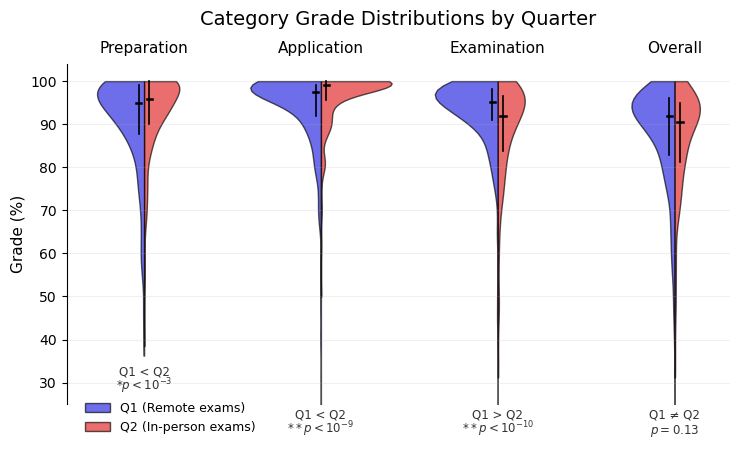

,Category,MWU U,MWU p-value,KS D,KS p-value,Q1 n,Q1 mean,Q1 median,Q2 n,Q2 mean,Q2 median,H0
0,Preparation,7.58e+04,2.88e-04,0.195,2.05e-07,491,90.09,94.97,361,92.69,95.90,Q1 < Q2
1,Application,6.64e+04,1.99e-10,0.246,1.45e-11,491,93.58,97.50,361,96.34,99.00,Q1 < Q2
2,Examination,1.12e+05,8.84e-11,0.205,4.07e-08,491,92.63,95.26,361,88.25,91.96,Q1 > Q2
3,Overall,9.41e+04,1.21e-01,0.083,1.07e-01,491,87.07,92.00,361,86.30,90.60,Q1 != Q2


In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import ks_2samp, mannwhitneyu, gaussian_kde


GRADE_COLS = ["Preparation", "Application", "Examination", "Overall"]

COURSE_LABELS = {
    "winter2025": "Q1 (Remote exams)",
    "fall2025": "Q2 (In-person exams)",
}

PALETTE = {
    "Q1 (Remote exams)": "blue",
    "Q2 (In-person exams)": "red",
}

ANNOTATIONS = {
    "Preparation": ("Q1 < Q2", r"$*p < 10^{-3}$"),
    "Application": ("Q1 < Q2", r"$**p < 10^{-9}$"),
    "Examination": ("Q1 > Q2", r"$**p < 10^{-10}$"),
    "Overall": ("Q1 ≠ Q2", r"$p = 0.13$"),
}

NULL_HYPOTHESES = {
    "Preparation": "Q1 < Q2",
    "Application": "Q1 < Q2",
    "Examination": "Q1 > Q2",
    "Overall": "Q1 != Q2",
}


def _prepare_grade_data(df, grade_cols=GRADE_COLS):
    df = df.copy()

    if "Total" in df.columns and "Overall" not in df.columns:
        df = df.rename(columns={"Total": "Overall"})

    df_long = df.melt(
        id_vars="course",
        value_vars=grade_cols,
        var_name="Category",
        value_name="Grade"
    )

    df_long["Quarter"] = df_long["course"].map(COURSE_LABELS)

    return df, df_long


def _compute_grade_stats(df, grade_cols=GRADE_COLS):
    rows = []

    for cat in grade_cols:
        winter = df.loc[df["course"] == "winter2025", cat].dropna()
        fall = df.loc[df["course"] == "fall2025", cat].dropna()

        mw = mannwhitneyu(winter, fall)
        ks = ks_2samp(winter, fall)

        rows.append({
            "Category": cat,
            "MWU U": mw.statistic,
            "MWU p-value": mw.pvalue,
            "KS D": ks.statistic,
            "KS p-value": ks.pvalue,
            "Q1 n": len(winter),
            "Q1 mean": winter.mean(),
            "Q1 median": winter.median(),
            "Q2 n": len(fall),
            "Q2 mean": fall.mean(),
            "Q2 median": fall.median(),
            "H0": NULL_HYPOTHESES[cat],
        })

    return pd.DataFrame(rows)


def _format_stats_for_display(stats_df):
    display_df = stats_df.copy()

    display_df["MWU U"] = display_df["MWU U"].map(lambda x: f"{x:.2e}")
    display_df["MWU p-value"] = display_df["MWU p-value"].map(lambda x: f"{x:.2e}")
    display_df["KS D"] = display_df["KS D"].map(lambda x: f"{x:.3f}")
    display_df["KS p-value"] = display_df["KS p-value"].map(lambda x: f"{x:.2e}")

    for col in ["Q1 mean", "Q1 median", "Q2 mean", "Q2 median"]:
        display_df[col] = display_df[col].map(lambda x: f"{x:.2f}")

    return display_df


def _print_latex_mwu_table(stats_df):
    latex_df = stats_df[["Category", "MWU U", "MWU p-value", "H0"]].copy()

    latex_df["MWU U"] = latex_df["MWU U"].map(lambda x: f"{x:.2e}")
    latex_df["MWU p-value"] = latex_df["MWU p-value"].map(lambda x: f"{x:.2e}")

    latex = latex_df.to_latex(
        index=False,
        escape=False,
        column_format="lccc",
        caption="Mann--Whitney U test results comparing category grades between quarters.",
        label="tab:mwu_results"
    )

    print(latex)


def _add_quartile_markers(ax, df, grade_cols=GRADE_COLS):
    for i, cat in enumerate(grade_cols):
        for side, course in zip(["left", "right"], ["winter2025", "fall2025"]):
            data = df.loc[df["course"] == course, cat].dropna()

            if len(data) == 0:
                continue

            q1, med, q3 = np.percentile(data, [25, 50, 75])
            x = i - 0.03 if side == "left" else i + 0.03

            ax.plot([x, x], [q1, q3], color="black", lw=1.2, zorder=6)
            ax.plot([x - 0.015, x + 0.015], [med, med], color="black", lw=1.8, zorder=7)


def _add_plot_annotations(ax, grade_cols=GRADE_COLS):
    heights = {
        "Preparation": {"upper": 31, "lower": 27},
        "Application": {"upper": 21, "lower": 17},
        "Examination": {"upper": 21, "lower": 17},
        "Overall": {"upper": 21, "lower": 17},
    }

    for i, cat in enumerate(grade_cols):
        label, pval = ANNOTATIONS[cat]

        ax.text(i, heights[cat]["upper"], label, ha="center", va="bottom", fontsize=8.5, color="0.2")
        ax.text(i, heights[cat]["lower"], pval, ha="center", va="bottom", fontsize=8.5, color="0.2")


def plot_grade_distributions(df_sub, save_path=None):

    df, df_long = _prepare_grade_data(df_sub)

    fig, ax = plt.subplots(figsize=(7.5, 4.6))

    sns.violinplot(
        data=df_long,
        x="Category",
        y="Grade",
        hue="Quarter",
        split=True,
        palette=PALETTE,
        inner=None,
        linewidth=1.0,
        cut=0,
        alpha=0.65,
        linecolor="black",
        ax=ax
    )

    ax.set_ylim(25, 104)
    ax.set_ylabel("Grade (%)", fontsize=11)
    ax.set_xlabel("")
    ax.set_title("Category Grade Distributions by Quarter", fontsize=14, pad=28)

    ax.grid(True, axis="y", linestyle="-", alpha=0.18)
    ax.grid(False, axis="x")

    ax.xaxis.set_label_position("top")
    ax.xaxis.tick_top()
    ax.tick_params(axis="x", labelsize=11, length=0, pad=6)
    ax.tick_params(axis="y", labelsize=10)

    ax.legend(
        title="",
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(0.01, 0.04),
        fontsize=9
    )

    _add_quartile_markers(ax, df)
    _add_plot_annotations(ax)

    sns.despine(ax=ax, left=False, bottom=True)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved figure to {save_path}")

    plt.show()

    stats_df = _compute_grade_stats(df)
    display(_format_stats_for_display(stats_df))

    return stats_df

stats_df = plot_grade_distributions(
    df_sub,
    save_path="out/category_grades_quarter_clean_quartiles2.png"
)